# Prospective analysis of the SPMS conformal prediction model (2025 data)

Evaluation of the conformal prediction model (trained on 2022 data) on the new visits registered until 2025,
and comparison with the Lorscheider criteria.

All paths are relative to this folder:

```
for_github/
├── analysis.ipynb
├── scripts/                  # helper functions used in this notebook
│   └── plot_utils/           # clone of https://github.com/pharmbio/plot_utils
├── data/
│   ├── 2022_data/            # train.csv, valid.csv, calib.csv, test.csv
│   └── 2025_data/            # 3_cleaned_data.csv, english_translated/skov.csv, english_translated/edss.csv
├── models/                   # icp.joblib (trained model), shap_values.joblib
└── images/                   # output figures
```

In [1]:
! git clone https://github.com/pharmbio/plot_utils.git

fatal: destination path 'plot_utils' already exists and is not an empty directory.


In [2]:
import os
import sys
import copy
import warnings

import numpy as np
import pandas as pd
import joblib
import matplotlib
import matplotlib.pyplot as plt
from collections import Counter

np.set_printoptions(suppress=True)
warnings.filterwarnings("ignore")

sys.path.append("scripts")

import sys
sys.path.append("plot_utils/python/src/")
from pharmbio.cp import metrics, plotting

import lorscheider_utils
from data_utils import (FEATURES, Y_LABEL, print_df_summary, load_2022_data, load_2025_data, load_relapse_and_edss,
                        merge_with_edss, get_exlusive_df, get_equivalent_2025_dataset, get_patient_groups,
                        get_pcodes_with_min_visits)
# lambda_fuction has to be in the notebook namespace for loading the saved ICP model
from model_utils import lambda_fuction, build_icp, train_icp, cp_predictions_to_labels, predict_labels
from cp_plots import plot_cp_plots
from lorscheider_analysis import get_lorscheider_stats, plot_the_lor_comparison_plot, extend_lor_progression
from metrics_utils import get_cm_from_lor_stats_df
from misclassification_utils import (get_per_patient_arrays, filter_by_max_time, get_mislabelled_mask,
                                     get_count_of_mis_per_visit, get_count_of_mis_per_year,
                                     get_total_count_per_visit, get_total_count_per_year,
                                     get_proportion_of_mis_vs_correct, plot_years_mislabelled,
                                     plot_grouped_mislabel_bars, plot_rate_with_significance,
                                     plot_per_label_misclassification, print_pairwise_power)

plotting.update_plot_settings(context='talk', font_scale=1.5)

In [3]:
# Relative paths
DATA_2022_DIR = "../2022_data"
DATA_2025_DIR = "../2025_data"
MODEL_DIR = "models"
MODEL_PATH = os.path.join(MODEL_DIR, "icp.joblib")
SHAP_VALUES_PATH = os.path.join(MODEL_DIR, "shap_values.joblib")
IMAGES_DIR = "images"
os.makedirs(IMAGES_DIR, exist_ok=True)

SIGNIFICANCE = 0.07
CLASS_LABELS = ['RRMS', 'SPMS']

# 2022 data

In [4]:
train_df, calib_df, test_df = load_2022_data(DATA_2022_DIR)

print_df_summary(train_df)
print_df_summary(calib_df)
print_df_summary(test_df)

79690 10067 Counter({0: 59898, 1: 19792})
5771 720 Counter({0: 4200, 1: 1571})
28323 3595 Counter({0: 21388, 1: 6935})


In [5]:
features = FEATURES
y_label = Y_LABEL

x_columns = features
y_columns = y_label
len(features)

27

# Model training

In [ ]:
# Set to True to retrain the model, otherwise the saved model is used
TRAIN_MODEL = False

def strip_icp(icp):
    icp.cal_x = None
    icp.cal_y = None

    nc = icp.nc_function
    nc.last_x = nc.last_y = nc.last_prediction = None

    adapter = nc.model
    adapter.last_x = adapter.last_y = None
    adapter.clean = False
    if hasattr(adapter, "train_x"):
        adapter.train_x = None

    # underlying sklearn model, if OOB was enabled
    est = adapter.model
    for a in ("oob_decision_function_", "oob_prediction_"):
        if hasattr(est, a):
            delattr(est, a)
    return icp

if TRAIN_MODEL:
    icp = build_icp(min_samples_split=2, n_estimators=150, min_samples_leaf=5,
                    criterion="gini", class_weight="balanced", max_depth=None)
    icp = train_icp(icp, train_df, calib_df, features, y_label, model_path=MODEL_PATH, rf_path=RF_PATH)
    icp = strip_icp(icp)
    joblib.dump(icp, MODEL_PATH)

# Model testing

In [7]:
icp = joblib.load(MODEL_PATH)

# 2025 data

In [8]:
df_2022 = pd.concat([train_df, calib_df, test_df])

df_2025 = load_2025_data(DATA_2025_DIR)
relapse_df, sub_edss_df = load_relapse_and_edss(DATA_2025_DIR)
len(df_2025["patient_code"].unique()), len(df_2025)

(19004, 158722)

In [9]:
df_2025_train_df = get_equivalent_2025_dataset(df_2025, train_df)
df_2025_calib_df = get_equivalent_2025_dataset(df_2025, calib_df)
df_2025_test_df = get_equivalent_2025_dataset(df_2025, pd.concat([train_df, calib_df]), inverse_pcode_selection=True)
print_df_summary(df_2025_train_df)
print_df_summary(df_2025_calib_df)
print_df_summary(df_2025_test_df)

102461 10052 Counter({0: 80777, 1: 21684})
7286 720 Counter({0: 5559, 1: 1727})
48975 8232 Counter({0: 39201, 1: 9774})


In [10]:
# Keep only the visits registered after the last visit used in 2022
df_2025_exclusive_train_df = get_exlusive_df(df_2025_train_df, train_df)
df_2025_exclusive_calib_df = get_exlusive_df(df_2025_calib_df, calib_df)
df_2025_exclusive_test_df = get_exlusive_df(df_2025_test_df, test_df)
print_df_summary(df_2025_exclusive_train_df)
print_df_summary(df_2025_exclusive_calib_df)
print_df_summary(df_2025_exclusive_test_df)

100%|██████████| 8232/8232 [00:01<00:00, 4282.65it/s]


22866 7777 Counter({0: 20989, 1: 1877})
1522 543 Counter({0: 1368, 1: 154})
20689 7399 Counter({0: 17877, 1: 2812})


In [11]:
df_2025_exclusive_merged_set = pd.concat([df_2025_exclusive_train_df, df_2025_exclusive_calib_df, df_2025_exclusive_test_df])
df_2025_exclusive_merged_set = df_2025_exclusive_merged_set.sort_values("visit_date")
len(df_2025_exclusive_merged_set["patient_code"].unique()), len(df_2025_exclusive_merged_set["patient_code"])

(15719, 45077)

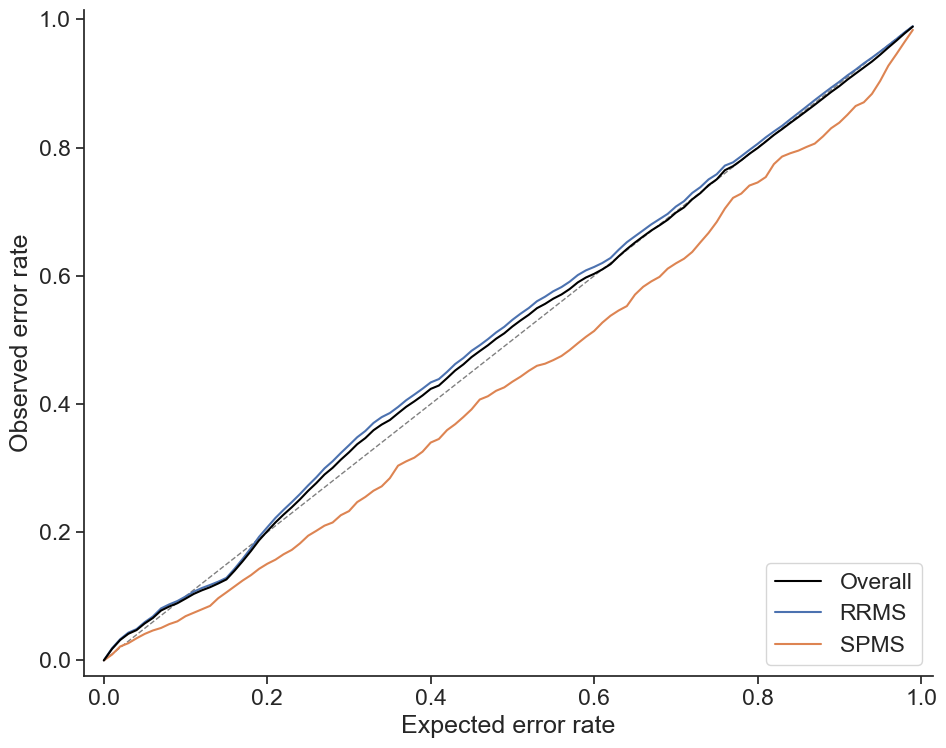

In [12]:
test_pvalues = icp.predict(df_2025_exclusive_merged_set[x_columns].values)
true_labels = df_2025_exclusive_merged_set[y_label].values.T.flatten()

matplotlib.rcParams.update({'font.size': 24})
plot = plotting.plot_calibration_clf(true_labels, test_pvalues, labels=CLASS_LABELS)
plt.xlabel("Expected error rate")
plt.ylabel("Observed error rate")
plt.savefig(os.path.join(IMAGES_DIR, "calibration_plot.pdf"), dpi=1000, bbox_inches='tight')
plt.show()

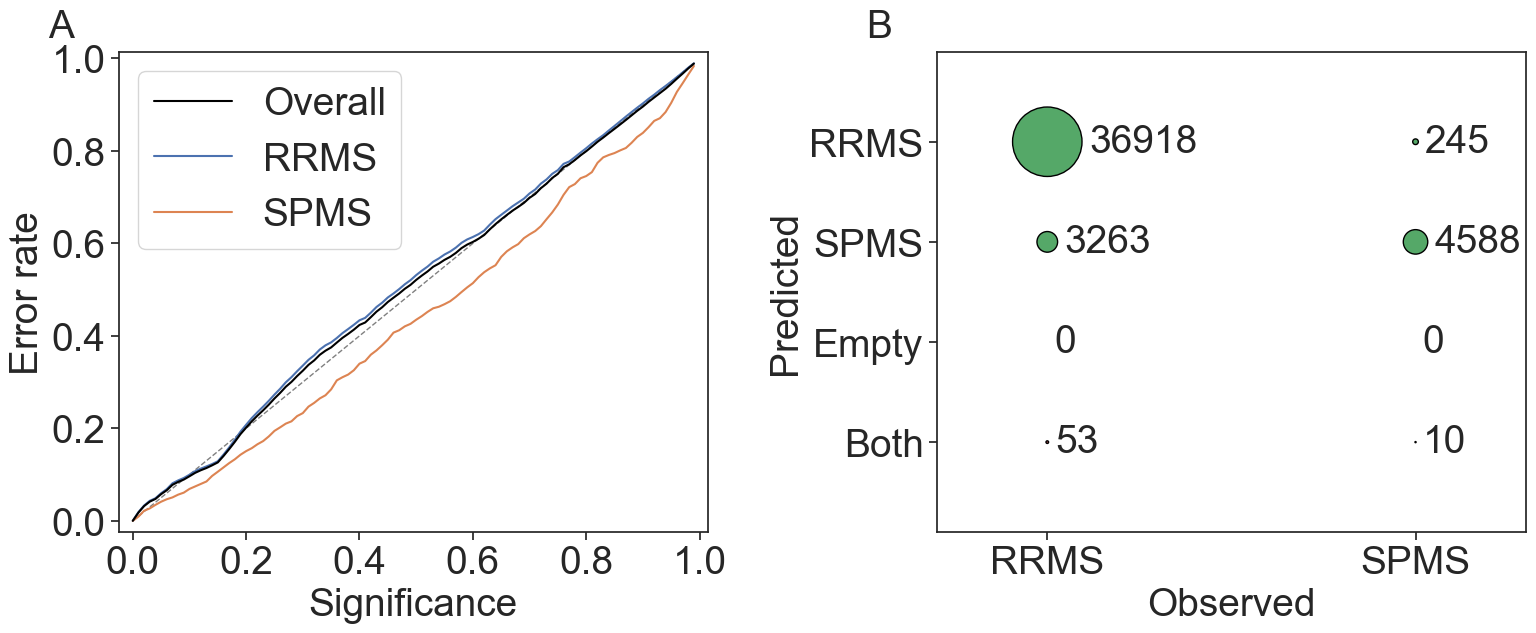

In [13]:
# For manuscript: Figure 1
matplotlib.rcParams.update({'font.size': 28})

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
ax1 = axes[0]  # Panel A
ax2 = axes[1]  # Panel B
plotting.plot_calibration_clf(true_labels, test_pvalues, labels=CLASS_LABELS, ax=ax1)
plotting.plot_confusion_matrix_bubbles(metrics.confusion_matrix(true_labels, test_pvalues, SIGNIFICANCE, labels=CLASS_LABELS), title="", ax=ax2)

ax1.text(-0.12, 1.03, "A", transform=axes[0].transAxes, fontsize=28)
ax2.text(-0.12, 1.03, "B", transform=axes[1].transAxes, fontsize=28)

ax1.tick_params(axis='both', labelsize=28)
ax1.xaxis.label.set_size(28)
ax1.yaxis.label.set_size(28)
ax1.set_xticks([0, 0.2, 0.4, 0.6, 0.8, 1])
ax1.spines['top'].set_visible(True)
ax1.spines['right'].set_visible(True)
ax1.legend(fontsize=28)

ax2.tick_params(axis='both', labelsize=28)
ax2.xaxis.label.set_size(28)
ax2.yaxis.label.set_size(28)
ax2.spines['top'].set_visible(True)
ax2.spines['right'].set_visible(True)

plt.tight_layout()
fig.savefig(os.path.join(IMAGES_DIR, "Figure_1.pdf"), format="pdf", bbox_inches="tight")

Criteria
Sensitivity (Recall): 0.1038
Specificity: 0.9869
Precision/PPV: 0.5833
NPV: 0.8617
Accuracy: 0.8543
F1: 0.1762
Model
Sensitivity (Recall): 0.9792
Specificity: 0.8910
Precision/PPV: 0.6136
NPV: 0.9959
Accuracy: 0.9043
F1: 0.7544


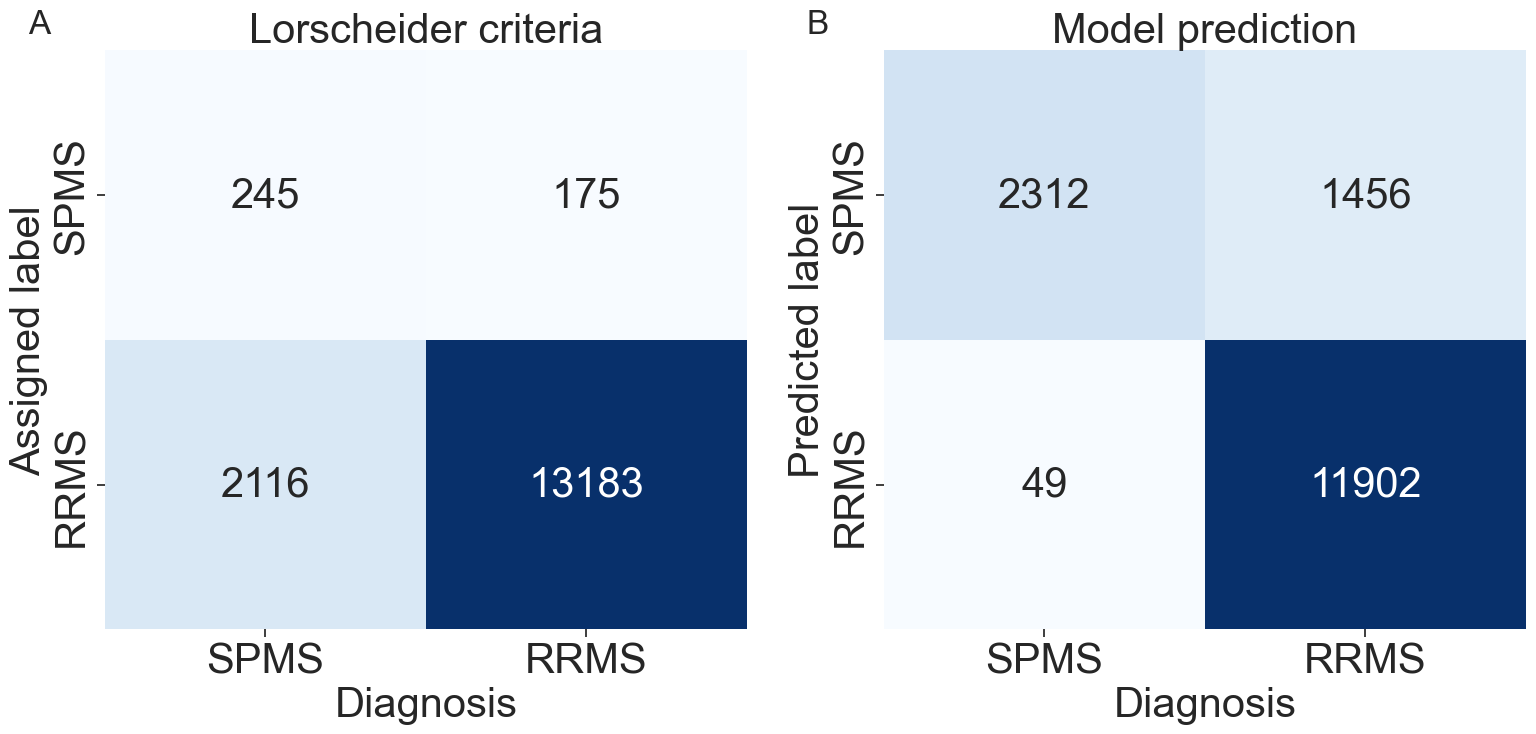

In [14]:
# Confusion matrices for the Lorscheider criteria and the model
fig, axes = plt.subplots(1, 2, figsize=(16, 8))
ax1 = axes[0]  # Panel A
ax2 = axes[1]  # Panel B

model_classify_df = get_lorscheider_stats(df_2025_exclusive_merged_set, icp, relapse_df, sub_edss_df, do_lor_specific_cutoff=False)
get_cm_from_lor_stats_df(model_classify_df, ax1=ax1, ax2=ax2)

ax1.text(-0.12, 1.03, "A", transform=axes[0].transAxes, fontsize=24)
ax2.text(-0.12, 1.03, "B", transform=axes[1].transAxes, fontsize=24)

plt.tight_layout()
fig.savefig(os.path.join(IMAGES_DIR, "cm_panel.pdf"), format="pdf", bbox_inches="tight", dpi=1000)

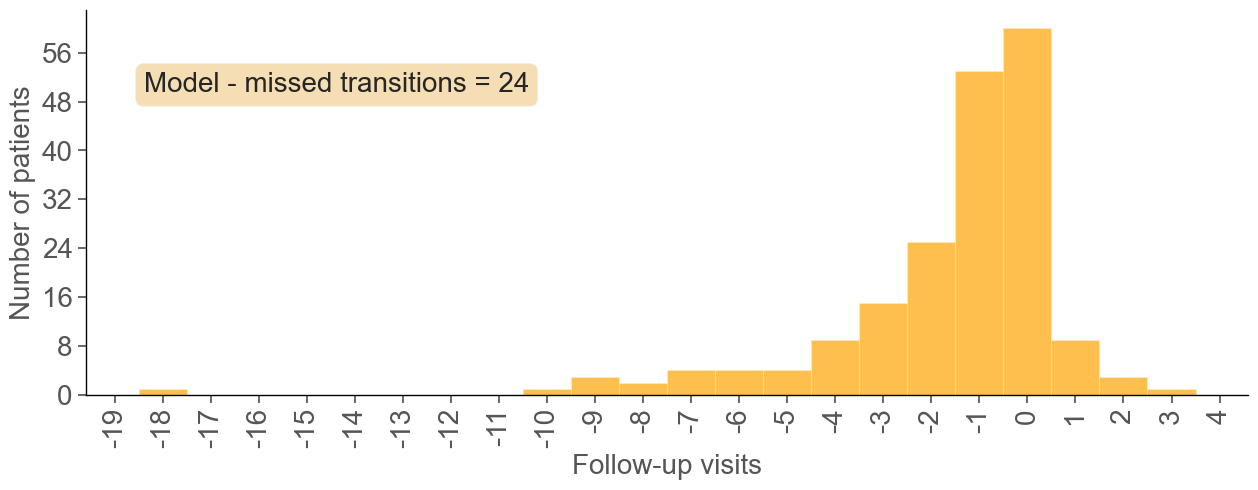

,Country,Total,Correct,One visit deviation,Early,Late,Correct_pred,One visit deviation_pred,Early_pred,Late_pred
0,SE,218,41,21,20,5,60,62,68,4


In [15]:
rrms_only_2025_pcodes, spms_only_2025_pcodes, patients_with_both_labels_only_2025 = get_patient_groups(df_2025_exclusive_merged_set)
transition_2025_df = df_2025_exclusive_merged_set[df_2025_exclusive_merged_set["patient_code"].isin(patients_with_both_labels_only_2025)]

plot_the_lor_comparison_plot(transition_2025_df,
                             transition_2025_df,
                             relapse_df,
                             sub_edss_df,
                             do_label_check=False,
                             plot_spms=True,
                             title="",
                             model=icp,
                             plot_only_model=True,
                             fig_title=os.path.join(IMAGES_DIR, "model_all_patients.pdf"),
                             return_axis=False)

Criteria
Sensitivity (Recall): 0.1038
Specificity: 0.9869
Precision/PPV: 0.5833
NPV: 0.8617
Accuracy: 0.8543
F1: 0.1762
Model
Sensitivity (Recall): 0.9792
Specificity: 0.8910
Precision/PPV: 0.6136
NPV: 0.9959
Accuracy: 0.9043
F1: 0.7544


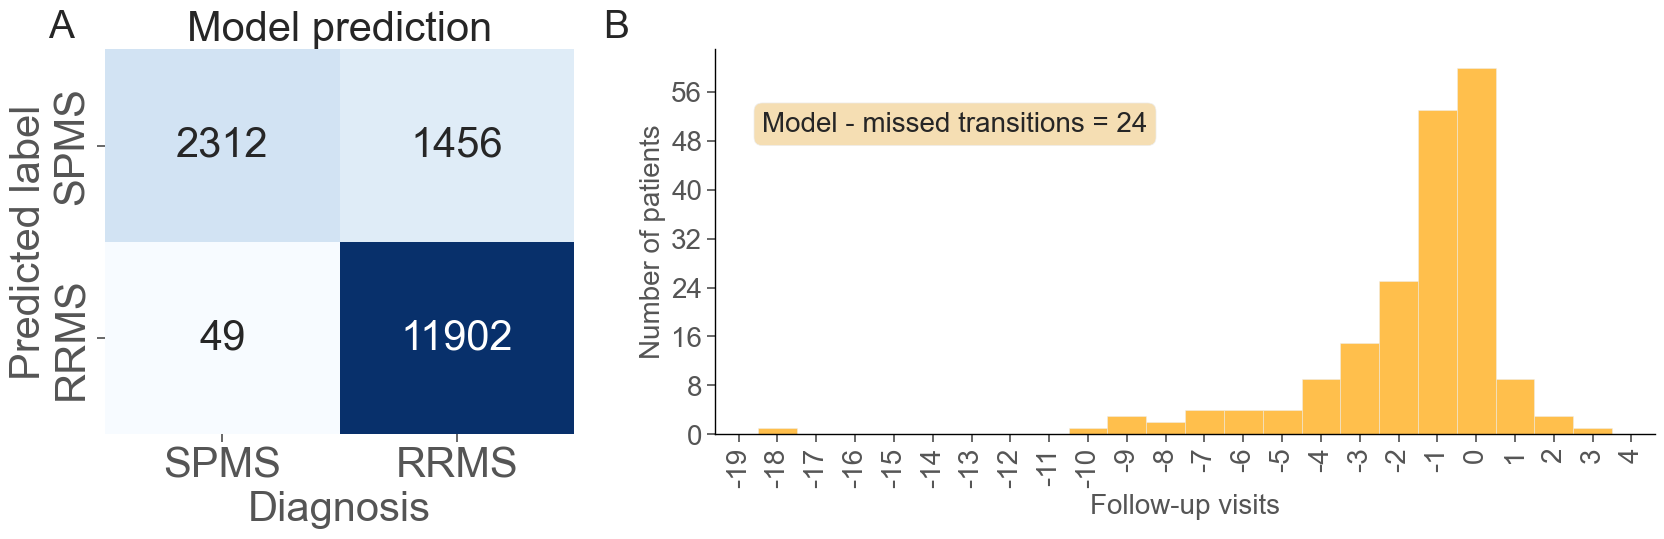

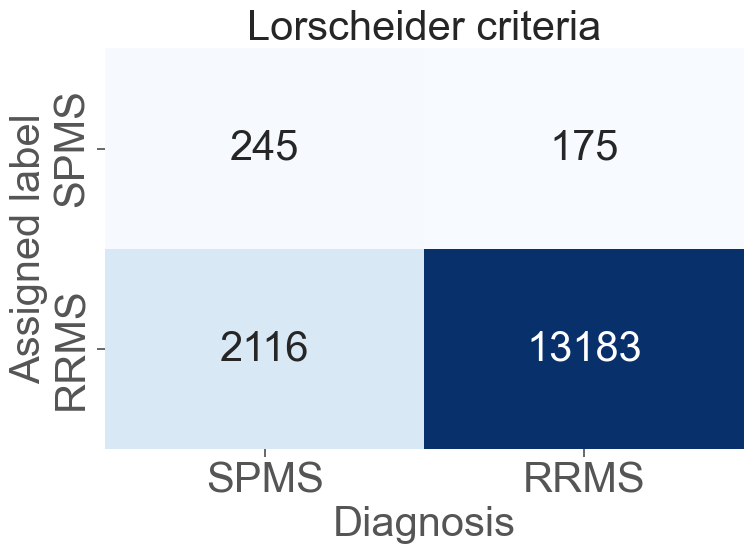

In [16]:
# For manuscript: Figure 2
fig = plt.figure(figsize=(20, 5))
fig.patch.set_facecolor('white')

gs = fig.add_gridspec(1, 2, width_ratios=[1, 2])
ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
for ax in [ax1, ax2]:
    ax.set_facecolor('white')

# Panel A: model confusion matrix (the Lorscheider matrix is drawn in a separate figure)
model_classify_df = get_lorscheider_stats(df_2025_exclusive_merged_set, icp, relapse_df, sub_edss_df, do_lor_specific_cutoff=False)
_, ax1 = get_cm_from_lor_stats_df(model_classify_df, ax1=None, ax2=ax1)

# Panel B: time difference to transition for the transitioning patients
_, ax2 = plot_the_lor_comparison_plot(transition_2025_df,
                                      transition_2025_df,
                                      relapse_df,
                                      sub_edss_df,
                                      do_label_check=False,
                                      plot_spms=True,
                                      title="",
                                      model=icp,
                                      plot_only_model=True,
                                      return_axis=True,
                                      ax1=ax2)

ax1.text(-0.12, 1.03, "A", transform=ax1.transAxes, fontsize=28)
ax2.text(-0.12, 1.03, "B", transform=ax2.transAxes, fontsize=28)

plt.tight_layout()
fig.savefig(os.path.join(IMAGES_DIR, "Figure_2.pdf"), format="pdf", bbox_inches="tight", dpi=1000)

In [17]:
len(rrms_only_2025_pcodes), len(spms_only_2025_pcodes), len(patients_with_both_labels_only_2025)

(13358, 2143, 218)

## Lorscheider criteria

In [18]:
# The Lorscheider criteria use all the visits (including the earlier ones) of the patients,
# restricted to patients with 3 or more visits
df_2025_rrms_lor_df = df_2025[df_2025["patient_code"].isin(rrms_only_2025_pcodes)]
df_2025_spms_lor_df = df_2025[df_2025["patient_code"].isin(spms_only_2025_pcodes)]
df_2025_transition_lor_df = df_2025[df_2025["patient_code"].isin(patients_with_both_labels_only_2025)]

matched_lor_rrms_pcodes = get_pcodes_with_min_visits(df_2025_rrms_lor_df, min_visits=3)
df_2025_rrms_lor_df = df_2025_rrms_lor_df[df_2025_rrms_lor_df["patient_code"].isin(matched_lor_rrms_pcodes)]

matched_lor_spms_pcodes = get_pcodes_with_min_visits(df_2025_spms_lor_df, min_visits=3)
df_2025_spms_lor_df = df_2025_spms_lor_df[df_2025_spms_lor_df["patient_code"].isin(matched_lor_spms_pcodes)]

matched_lor_transition_pcodes = get_pcodes_with_min_visits(df_2025_transition_lor_df, min_visits=3)
df_2025_transition_lor_df = df_2025_transition_lor_df[df_2025_transition_lor_df["patient_code"].isin(matched_lor_transition_pcodes)]

df_2025_exclusive_all_visits_for_lor = pd.concat([df_2025_rrms_lor_df, df_2025_spms_lor_df, df_2025_transition_lor_df])
df_2025_exclusive_all_visits_for_lor = df_2025_exclusive_all_visits_for_lor.sort_values("visit_date")

len(matched_lor_rrms_pcodes), len(matched_lor_spms_pcodes), len(matched_lor_transition_pcodes)

(10750, 1809, 202)

In [19]:
# Same patients for the model, but only with the new (2025 exclusive) visits
matched_lor_pcodes = np.hstack([matched_lor_rrms_pcodes, matched_lor_spms_pcodes, matched_lor_transition_pcodes])
for_model_df = df_2025_exclusive_merged_set[df_2025_exclusive_merged_set["patient_code"].isin(matched_lor_pcodes)]
for_model_df = for_model_df.sort_values("visit_date")

In [20]:
model_classify_df = get_lorscheider_stats(for_model_df, icp, relapse_df, sub_edss_df, do_lor_specific_cutoff=False)

for_lor_df = df_2025_exclusive_all_visits_for_lor
lor_classify_df = get_lorscheider_stats(for_lor_df, icp, relapse_df, sub_edss_df, do_lor_specific_cutoff=False)

model_lor_classify_df = copy.deepcopy(model_classify_df)
model_lor_classify_df["rrms_lor"] = lor_classify_df["rrms_lor"]
model_lor_classify_df["spms_lor"] = lor_classify_df["spms_lor"]
model_lor_classify_df["transition_lor"] = lor_classify_df["transition_lor"]
model_lor_classify_df

,rrms_gt,spms_gt,transition_gt,rrms_lor,spms_lor,transition_lor,rrms,spms,transition
SE,10750,1809,202,677,531,899,1202,1796,181


Criteria
Sensitivity (Recall): 0.7111
Specificity: 0.9370
Precision/PPV: 0.6787
NPV: 0.9455
Accuracy: 0.9014
F1: 0.6945
Model
Sensitivity (Recall): 0.9831
Specificity: 0.8882
Precision/PPV: 0.6219
NPV: 0.9965
Accuracy: 0.9031
F1: 0.7618


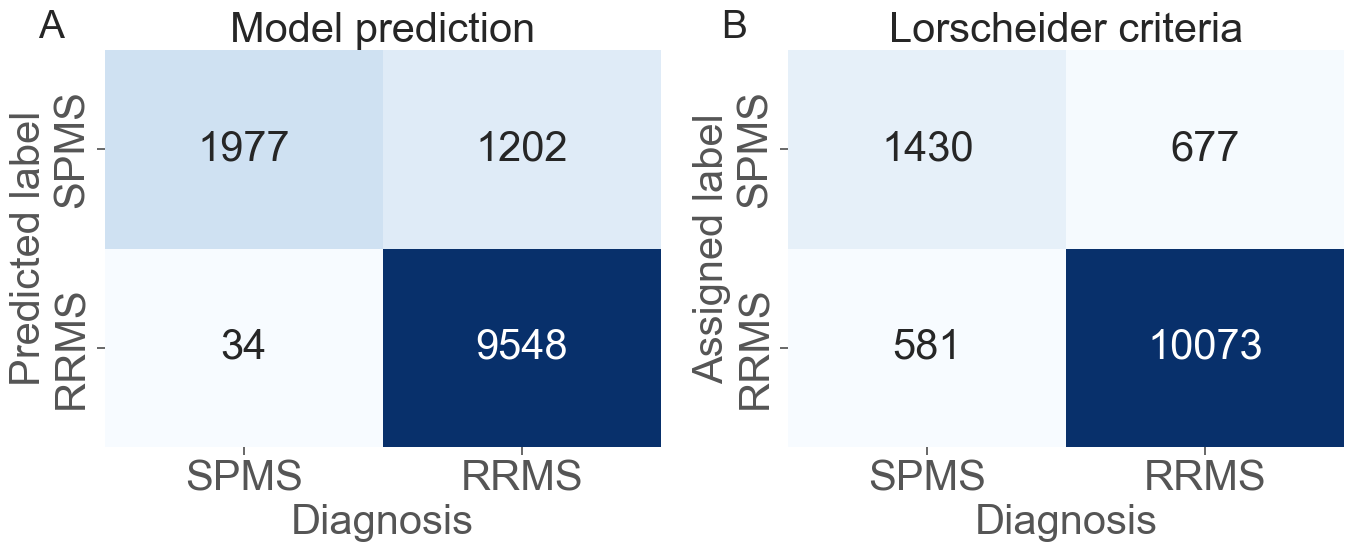

In [21]:
# For manuscript: Figure 3 (A: model, B: Lorscheider criteria)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
ax1 = axes[0]  # Panel A
ax2 = axes[1]  # Panel B

get_cm_from_lor_stats_df(model_lor_classify_df, ax1=ax2, ax2=ax1)

ax1.text(-0.12, 1.03, "A", transform=axes[0].transAxes, fontsize=28)
ax2.text(-0.12, 1.03, "B", transform=axes[1].transAxes, fontsize=28)

plt.tight_layout()
fig.savefig(os.path.join(IMAGES_DIR, "Figure_3.pdf"), format="pdf", bbox_inches="tight", dpi=1000)

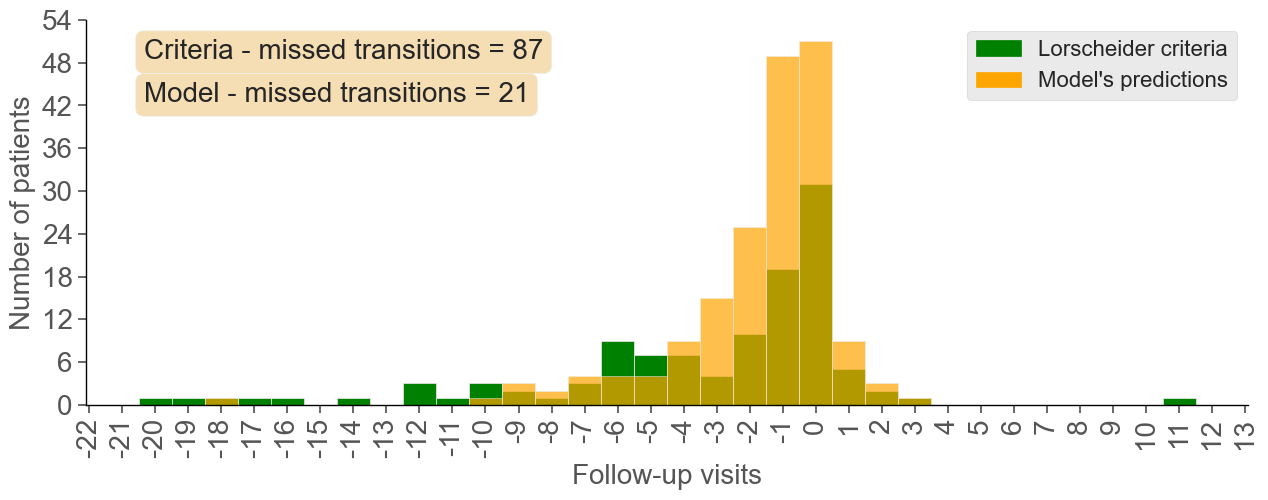

,Country,Total,Correct,One visit deviation,Early,Late,Correct_pred,One visit deviation_pred,Early_pred,Late_pred
0,SE,202,31,24,56,4,51,58,68,4


In [22]:
# For manuscript: Figure 5
for_model_transition_df = df_2025_exclusive_merged_set[df_2025_exclusive_merged_set["patient_code"].isin(matched_lor_transition_pcodes)]
for_model_transition_df = for_model_transition_df.sort_values("visit_date")
df_2025_transition_lor_df = df_2025_transition_lor_df.sort_values("visit_date")

plot_the_lor_comparison_plot(for_model_transition_df,
                             df_2025_transition_lor_df,
                             relapse_df,
                             sub_edss_df,
                             do_label_check=False,
                             plot_spms=True,
                             title="",
                             model=icp,
                             plot_only_model=False,
                             fig_title=os.path.join(IMAGES_DIR, "Figure_5.pdf"))

# Venn diagram / Upset plot

In [23]:
# Model predictions per visit (0 = RRMS, 1 = SPMS, 2 = both, 3 = empty)
for_model_pred_df = copy.deepcopy(for_model_df).reset_index(drop=True)
for_model_pred_df["pred"] = predict_labels(icp, for_model_pred_df, x_columns, SIGNIFICANCE)

model_rrms_pcodes, model_spms_pcodes, model_transition_pcodes = [], [], []
for pcode in for_model_pred_df["patient_code"].unique():
    sub_df = for_model_pred_df[for_model_pred_df["patient_code"] == pcode]
    if 1 in sub_df["pred"].to_list():
        if 0 in sub_df["pred"].to_list():
            model_transition_pcodes.append(pcode)
        else:
            model_spms_pcodes.append(pcode)
    else:
        model_rrms_pcodes.append(pcode)

len(model_rrms_pcodes), len(model_spms_pcodes), len(model_transition_pcodes)

(9582, 2381, 798)

In [24]:
# Lorscheider criteria on all visits
merged_lor_only_2025_test_df = merge_with_edss(df_2025_exclusive_all_visits_for_lor, sub_edss_df)
merged_lor_only_2025_test_df, _ = lorscheider_utils.plot_lorscheider(merged_lor_only_2025_test_df, relapse_df, ccode="SE", do_label_check=False)

lor_rrms_pcodes, lor_spms_pcodes = [], []
for pcode in merged_lor_only_2025_test_df["patient_code"].unique():
    sub_df = merged_lor_only_2025_test_df[merged_lor_only_2025_test_df["patient_code"] == pcode]
    if 1 in sub_df["lor_progression"].to_list():
        lor_spms_pcodes.append(pcode)
    else:
        lor_rrms_pcodes.append(pcode)

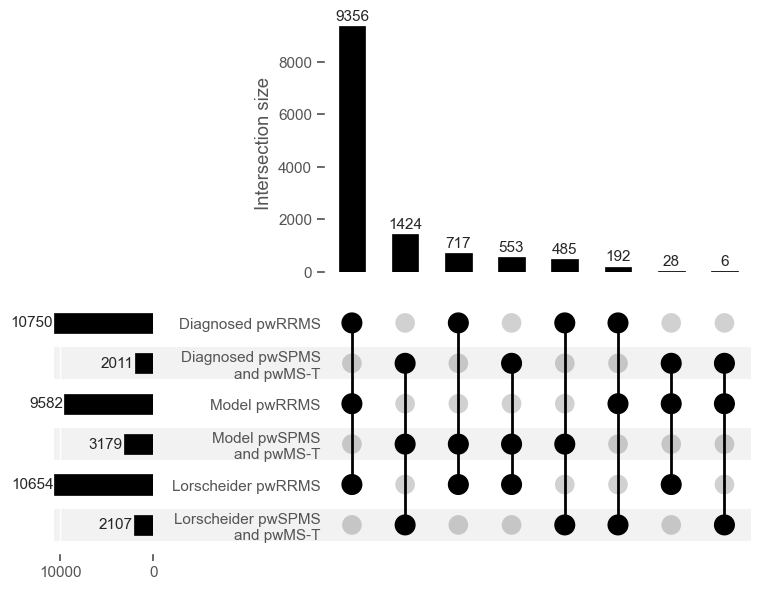

In [25]:
# For manuscript: Figure 4
from upsetplot import UpSet, from_indicators

RRMS = set(matched_lor_rrms_pcodes)
SPMS = set(matched_lor_spms_pcodes)
Transitioning = set(matched_lor_transition_pcodes)
model_RRMS = set(model_rrms_pcodes)
model_SPMS = set(model_spms_pcodes)
model_Transitioning = set(model_transition_pcodes)
lor_RRMS = set(lor_rrms_pcodes)
lor_SPMS = set(lor_spms_pcodes)

sets = {"Diagnosed pwRRMS": RRMS, "Diagnosed pwSPMS\nand pwMS-T": SPMS.union(Transitioning),
        "Model pwRRMS": model_RRMS, "Model pwSPMS\nand pwMS-T": model_SPMS.union(model_Transitioning),
        "Lorscheider pwRRMS": lor_RRMS, "Lorscheider pwSPMS\nand pwMS-T": lor_SPMS}

# Boolean indicator table: rows = patients, columns = set names
elements = sorted(set().union(*sets.values()))
df = pd.DataFrame({name: [e in s for e in elements] for name, s in sets.items()}, index=elements)
desired_order = list(sets.keys())[::-1]
df = df[desired_order]

plt.rcParams.update({"font.size": 11, "xtick.labelsize": 11, "ytick.labelsize": 11})

fig, axes = plt.subplots(1, figsize=(9, 7), facecolor="white")
for ax in fig.get_axes():
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
    for side in ['top', 'right', 'bottom', 'left']:
        ax.spines[side].set_visible(False)

up = UpSet(from_indicators(df),
           show_counts=True,
           element_size=None,
           subset_size="count",
           sort_by="cardinality",
           sort_categories_by=None)  # keep the column order above
up.plot(fig)
for ax in fig.get_axes():
    ax.set_facecolor("white")
plt.savefig(os.path.join(IMAGES_DIR, "Figure_4.pdf"), dpi=1000, bbox_inches='tight')
plt.show()

# Baseline year basis for model df without lor criteria

In [26]:
# RRMS patients only (never diagnosed SPMS in the 2025 exclusive visits)
for_2025_model_df = copy.deepcopy(df_2025_exclusive_merged_set)
all_spms_transition_2025_pcodes = for_2025_model_df[for_2025_model_df["y_label"] == 1]["patient_code"].unique()
all_rrms_2025_pcodes = set(for_2025_model_df[for_2025_model_df["y_label"] == 0]["patient_code"].unique()) - set(all_spms_transition_2025_pcodes)
all_rrms_2025_pcodes = [int(entry) for entry in all_rrms_2025_pcodes]

rrms_for_2025_model_df = for_2025_model_df[for_2025_model_df["patient_code"].isin(all_rrms_2025_pcodes)]
rrms_for_2025_model_df["pred"] = predict_labels(icp, rrms_for_2025_model_df, x_columns, SIGNIFICANCE)
rrms_for_2025_model_df = rrms_for_2025_model_df.sort_values("visit_date")

In [27]:
years_array, value_arrays = get_per_patient_arrays(rrms_for_2025_model_df, ["pred", "y_label"], time_basis="years")
years_array, value_arrays = filter_by_max_time(years_array, value_arrays, max_time=5)
all_pred_arr, all_diagnosis_arr = value_arrays["pred"], value_arrays["y_label"]

years_pred_total_mislabelled = years_array[get_mislabelled_mask(all_diagnosis_arr, all_pred_arr)]
years_pred_count_mis = np.array(get_count_of_mis_per_year(years_pred_total_mislabelled, years_array))
total_count_per_year = get_total_count_per_year(years_array)
total_count_per_year

100%|██████████| 13358/13358 [00:03<00:00, 4409.81it/s]


array([16870,  8764,  5671,  4401,  2077])

Num combinations = 10
Adjusted p-values for 0.05 0.005
Adjusted p-values for 0.01 0.001
Adjusted p-values for 0.001 0.0001
Adjusted p-values for 0.0001 1e-05


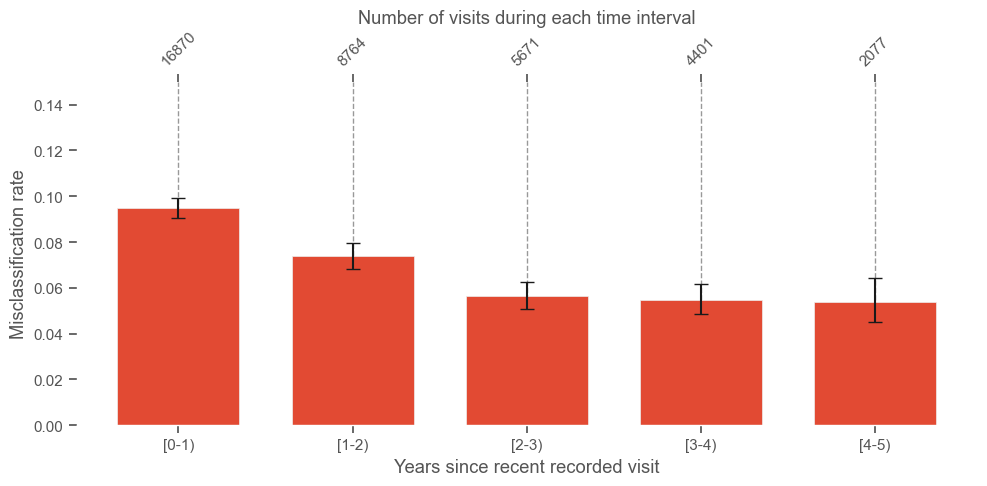

In [28]:
plot_years_mislabelled(years_pred_count_mis, total_count_per_year, y_lim=0.15,
                       fig_title=os.path.join(IMAGES_DIR, "misclassification_rate_model.jpeg"))

# SHAP

In [29]:
import shap

rf_clf = icp.nc_function.model.model
for_shap_df = df_2025_exclusive_merged_set.sample(1000)[x_columns]

feature_names_for_shap = [entry.replace("_", " ") for entry in list(for_shap_df.columns)]
feature_names_for_shap[feature_names_for_shap.index('revised debut age')] = "debut age"
for_shap_df.columns = feature_names_for_shap

In [30]:
explainer = shap.Explainer(rf_clf, for_shap_df)
shap_values = explainer(for_shap_df, check_additivity=False)
joblib.dump(shap_values, SHAP_VALUES_PATH)

 99%|===================| 1987/2000 [00:48<00:00]        

['models/shap_values.joblib']

In [31]:
shap_values = joblib.load(SHAP_VALUES_PATH)

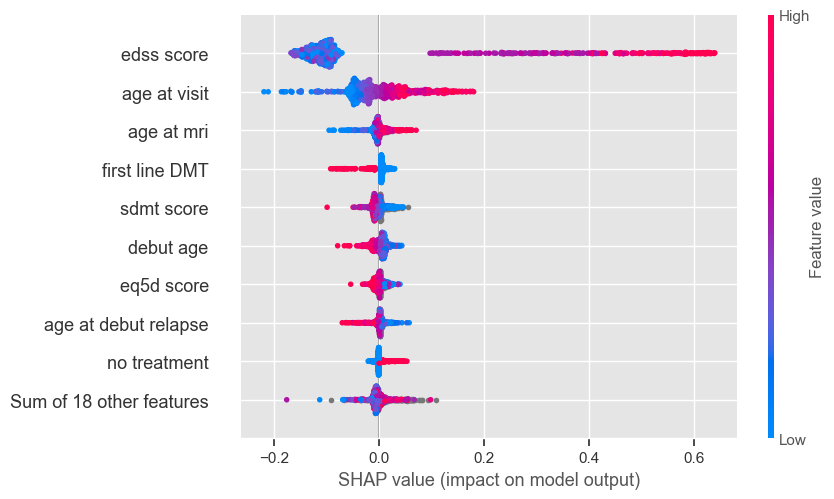

In [32]:
plt.clf()
shap.plots.beeswarm(shap_values[:, :, 1], show=False)
plt.savefig(os.path.join(IMAGES_DIR, "shap_beeswarm_plot.pdf"), dpi=1000, bbox_inches='tight')

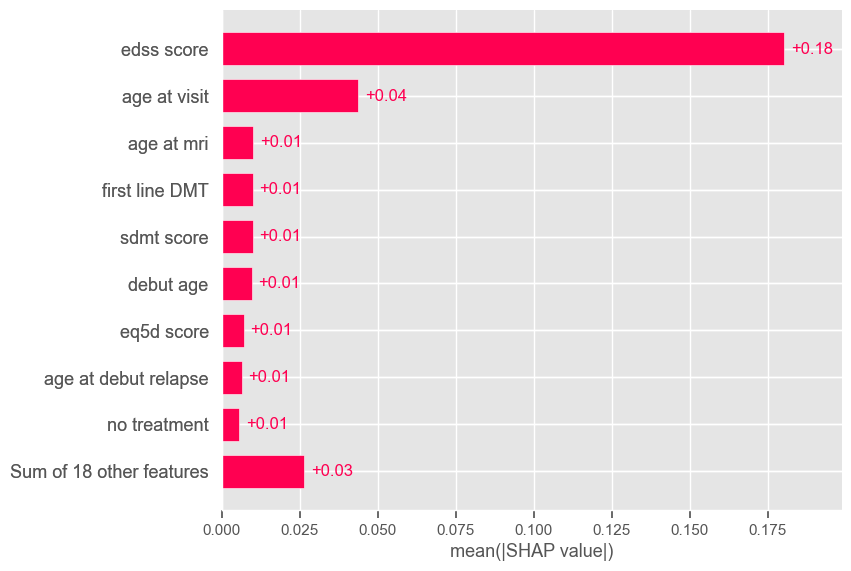

In [33]:
plt.clf()
shap.plots.bar(shap_values[:, :, 1], show=False)
plt.savefig(os.path.join(IMAGES_DIR, "shap_barplot.pdf"), dpi=1000, bbox_inches='tight')